# CAB420 Assignment 1A Question 2: Template
Simon Denman (s.denman@qut.edu.au)

## Overview

This notebook provides a brief template for CAB420 Assignment 1A, Question 2. It simply implements the data loading, and splitting the data into the predictors and response. You are to use the data splits defined here in your response.

The template also provides other suggestions around how to approach the problem.

Please make sure you read the assignment brief on canvas, and check the FAQ for other information.

**Note: File paths used in this template may need to change for your local machine. Please set these based on your local file system structure.**

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV
from scipy.stats import norm
from sklearn.model_selection import PredefinedSplit
from sklearn.metrics import classification_report

Mounted at /content/drive


In [2]:
# load data
train = pd.read_csv('/content/drive/MyDrive/CAB420/ASSESSMENTS/ASSESSMENT_1A/Q2/training.csv')
val = pd.read_csv('/content/drive/MyDrive/CAB420/ASSESSMENTS/ASSESSMENT_1A/Q2/validation.csv')
test = pd.read_csv('/content/drive/MyDrive/CAB420/ASSESSMENTS/ASSESSMENT_1A/Q2/testing.csv')

# pull out X and y data, convert to numpy
X_train = train.iloc[:,1:].to_numpy()
Y_train = train.iloc[:,0].to_numpy()
X_val = val.iloc[:,1:].to_numpy()
Y_val = val.iloc[:,0].to_numpy()
X_test = test.iloc[:,1:].to_numpy()
Y_test = test.iloc[:,0].to_numpy()

In [ ]:
# If you wish to pre-process the data, do so here. In your write-up, outline why you choose to do, or choose not to do, any
# pre-processing

In [3]:
# Q2 asks you to use a grid search for each model. You are to evaluate the models on the validation set, and train on the train
# set. If you wish to use sklearn's GridSearchCV, you will need to setup a PredefinedSplit to pass into this. An appropraite
# PredefinedSplit object is created below.
X_train_and_val = np.vstack((X_train, X_val))
Y_train_and_val = np.hstack((Y_train, Y_val))
mask = np.zeros(len(Y_train_and_val))
mask[0:len(Y_train)] = -1
train_val_split = PredefinedSplit(mask)
def eval_model(model, X_train, Y_train, X_test, Y_test):
    fig = plt.figure(figsize=[25, 8])
    ax = fig.add_subplot(1, 2, 1)
    conf = ConfusionMatrixDisplay.from_estimator(model, X_train, Y_train, normalize='true', ax=ax)
    conf.ax_.set_title('Training Set Performance: %1.3f' % (sum(model.predict(X_train) == Y_train)/len(Y_train)));
    ax = fig.add_subplot(1, 2, 2)
    conf = ConfusionMatrixDisplay.from_estimator(model, X_test, Y_test, normalize='true', ax=ax)
    conf.ax_.set_title('Testing Set Performance: %1.3f' % (sum(model.predict(X_test) == Y_test)/len(Y_test)));
    print(classification_report(Y_test, model.predict(X_test)))

BEST: k = 4, weight = distance, metric = minkowski
              precision    recall  f1-score   support

          d        0.85      0.87      0.86        53
          h        0.64      0.93      0.76        15
          o        0.95      0.68      0.79        31
          s        0.87      0.89      0.88        62

    accuracy                           0.84       161
   macro avg       0.83      0.84      0.82       161
weighted avg       0.86      0.84      0.85       161



Streaming output truncated to the last 5000 lines.
                    ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_pairwise_distances_reduction/_dispatcher.py", line 593, in compute
    unique_Y_labels=np.array(unique_Y_labels, dtype=np.intp),
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ValueError: invalid literal for int() with base 10: 'd '

  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_scorer.py", line 472, in __call__
 

Best Parameters: {'metric': 'minkowski', 'n_neighbors': 19, 'weights': 'distance'}
              precision    recall  f1-score   support

          d        0.87      0.74      0.80        53
          h        0.67      0.93      0.78        15
          o        0.95      0.68      0.79        31
          s        0.75      0.89      0.81        62

    accuracy                           0.80       161
   macro avg       0.81      0.81      0.80       161
weighted avg       0.82      0.80      0.80       161



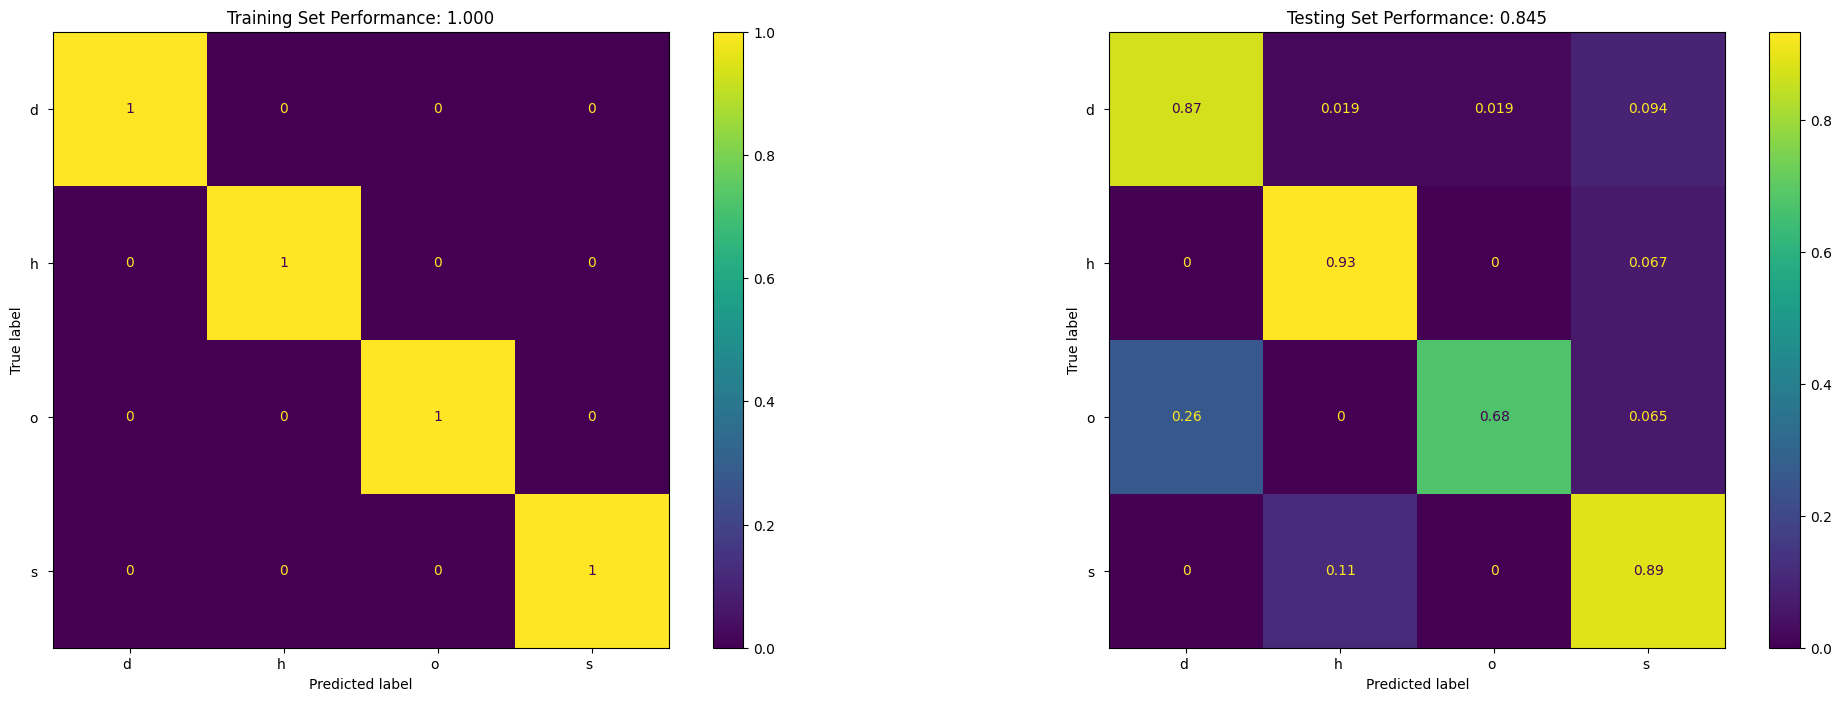

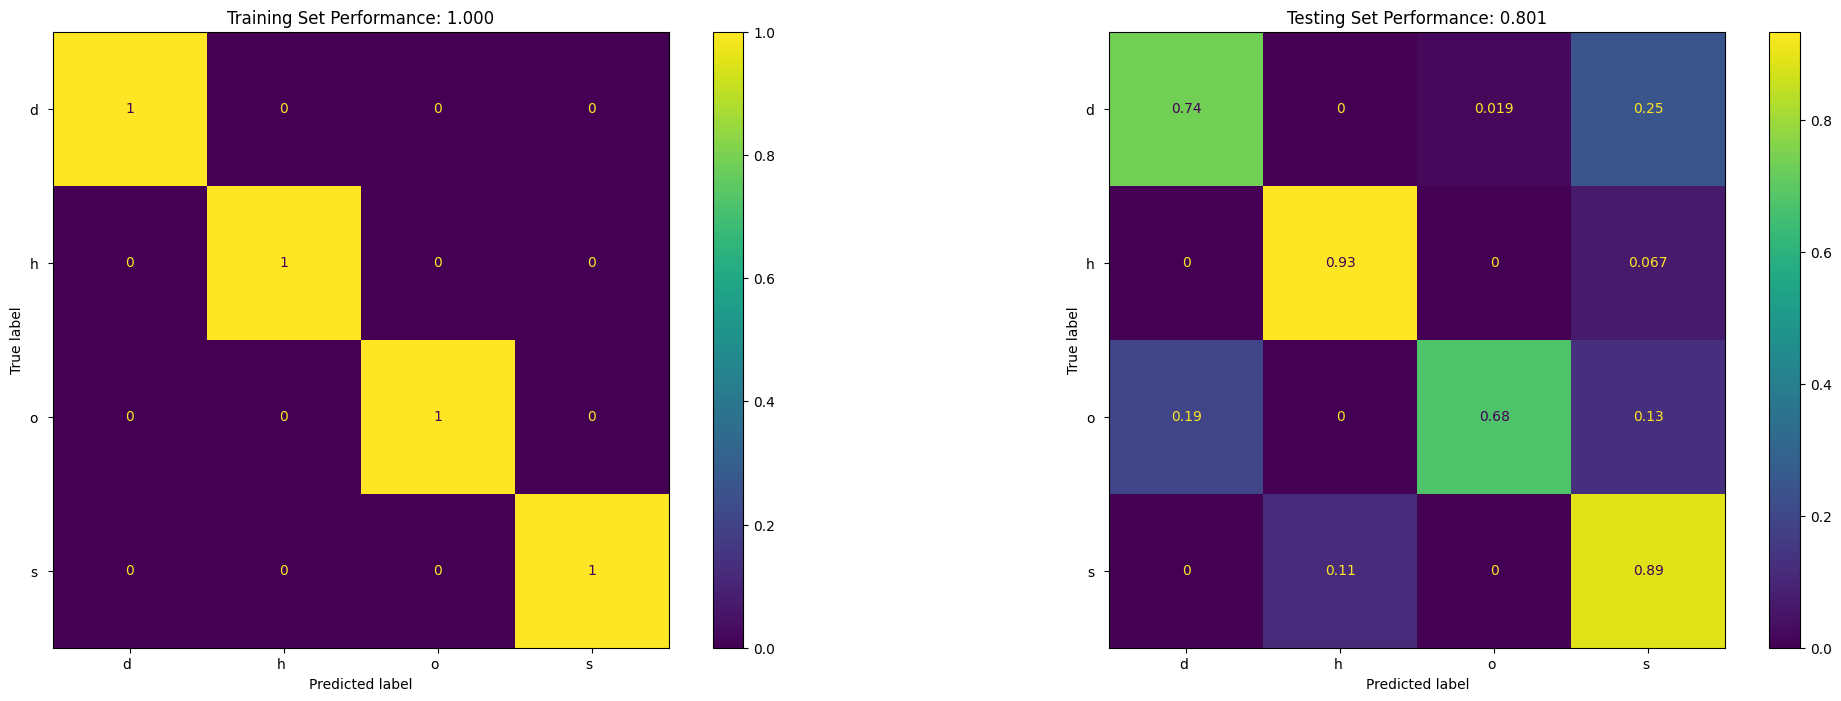

In [23]:
# Train your CKNN. You should consider the following parameters at least:
#  - K
#  - Distance Metric
#  - Weighting Scheme
# Please note, you'd don't need to find the "perfect" parameters. The grid search does not need to consider every possible value,
# and can be quite coarse to avoid long run-times. You may also wish to conduct a rough search first, and then a refined search,
# though this is not required.

#for k in [1,2,5,10]:
  #cknn = KNeighborsClassifier(n_neighbors=k, weights='uniform')
  #cknn.fit(X_train, Y_train)
  #eval_model(cknn, X_train, Y_train, X_test, Y_test)
#for k in [1,2,5,10]:
  #cknn = KNeighborsClassifier(n_neighbors=k, weights='distance')
  #cknn.fit(X_train, Y_train)
  #eval_model(cknn, X_train, Y_train, X_test, Y_test)

## WEIGHT(DISTANCE) = BEST
#or k in [1,2,5,10]:
  #cknn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='minkowski')
  #cknn.fit(X_train, Y_train)
  #eval_model(cknn, X_train, Y_train, X_test, Y_test)
#for k in [1,2,5,10]:
  #cknn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='manhattan')
  #cknn.fit(X_train, Y_train)
  #eval_model(cknn, X_train, Y_train, X_test, Y_test)

## Check K = 1,2,4,8, weights = distance, metric = both
#for k in [1,2,4]:
  #cknn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='minkowski')
  #cknn.fit(X_train, Y_train)
  #eval_model(cknn, X_train, Y_train, X_test, Y_test)
#for k in [1,2,4]:
  #cknn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='manhattan')
  #cknn.fit(X_train, Y_train)
  #eval_model(cknn, X_train, Y_train, X_test, Y_test)

cknnBEST = KNeighborsClassifier(n_neighbors=4, weights='distance', metric='minkowski')
cknnBEST.fit(X_train, Y_train)
print("BEST: k = 4, weight = distance, metric = minkowski")
eval_model(cknnBEST, X_train, Y_train, X_test, Y_test)

param_grid = [
    {'n_neighbors': list(range(3,198)),
     'weights': ['uniform', 'distance'],
     'metric': ['minkowski', 'manhattan']}
]
cknn = KNeighborsClassifier()
grid_search = GridSearchCV(cknn, param_grid, cv=train_val_split)  # Specify scoring metric
grid_search.fit(X_train_and_val, Y_train_and_val)
grid_search.cv_results_
best_index = np.argmin(grid_search.cv_results_['rank_test_score'])
params = grid_search.cv_results_['params'][best_index]
print("Best Parameters:", params)
cknn = KNeighborsClassifier().set_params(**params)
cknn.fit(X_train, Y_train)
eval_model(cknn, X_train, Y_train, X_test, Y_test)



{'C': 10, 'degree': 15, 'kernel': 'poly'}
              precision    recall  f1-score   support

          d        0.84      0.77      0.80        53
          h        0.61      0.93      0.74        15
          o        0.85      0.71      0.77        31
          s        0.86      0.87      0.86        62

    accuracy                           0.81       161
   macro avg       0.79      0.82      0.79       161
weighted avg       0.83      0.81      0.81       161



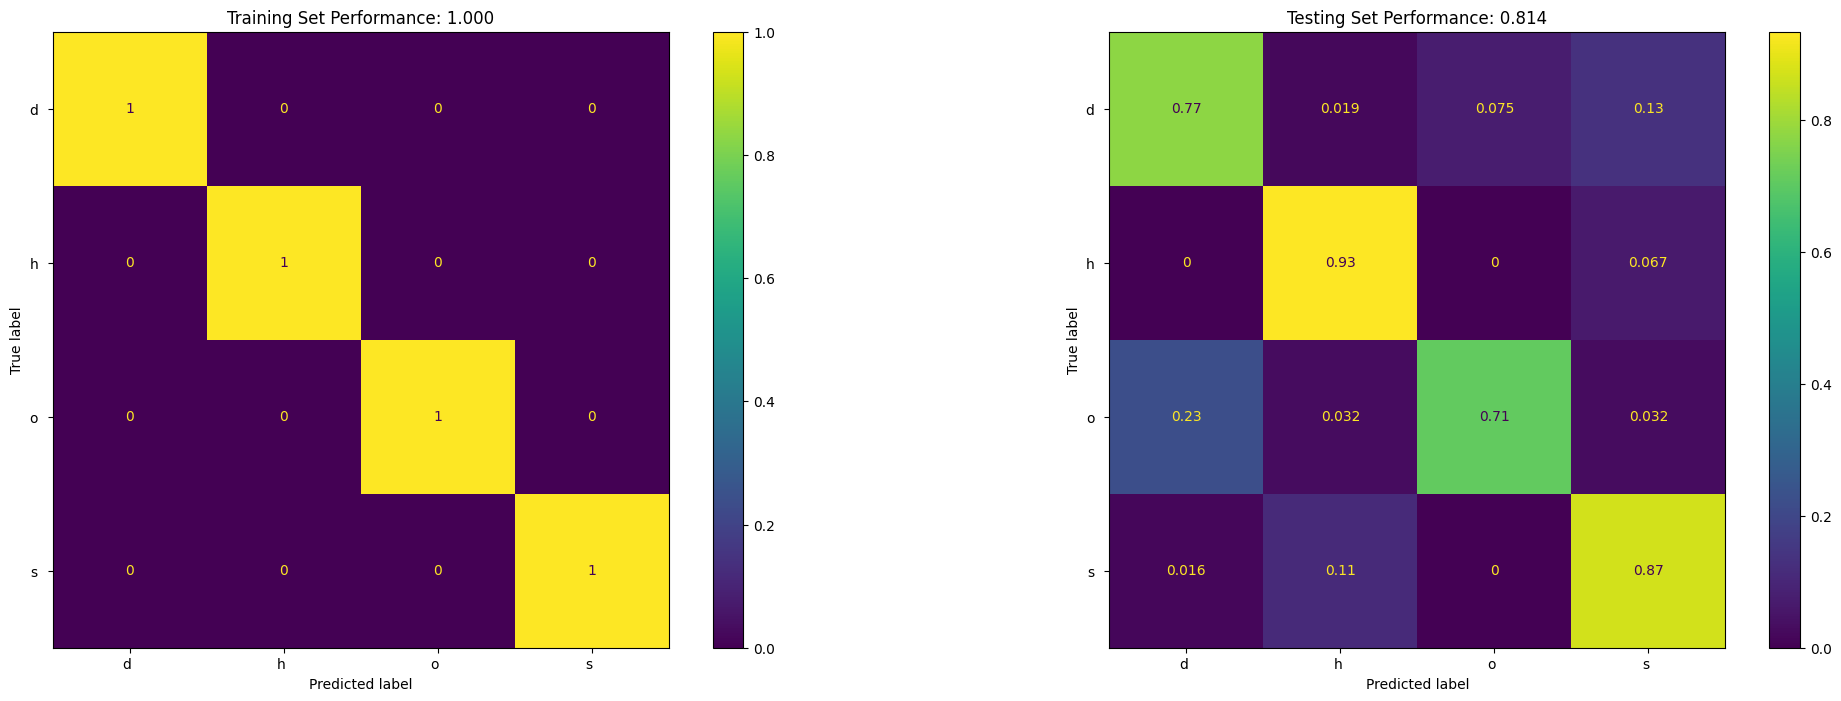

In [24]:
# Train your SVM. You should consider the following parameters at least:
#  - C
#  - Kernel Type
#  - Kernel Parameters
#  - Ensemble scheme (i.e. "one vs one" or "one vs all")
# Please note, you'd don't need to find the "perfect" parameters. The grid search does not need to consider every possible value,
# and can be quite coarse to avoid long run-times. You may also wish to conduct a rough search first, and then a refined search,
# though this is not required.
param_grid = [
  {'C': [0.01,0.1, 1, 10, 100,1000], 'kernel': ['linear']},
  {'C': [0.01,0.1, 1, 10, 100,1000], 'gamma': [1,0.1, 0.01, 0.001], 'kernel': ['rbf']},
  {'C': [0.01,0.1, 1, 10, 100,1000], 'degree': [1,3, 4, 5,7,9,11,13,15,17,19,21,23,25,27,29,31,33,35,37,39], 'kernel': ['poly']},
 ]
svm = SVC(class_weight='balanced')
grid_search = GridSearchCV(svm, param_grid, cv=train_val_split)
grid_search.fit(X_train_and_val, Y_train_and_val)
grid_search.cv_results_
best_system = np.argmin(grid_search.cv_results_['rank_test_score'])
params = grid_search.cv_results_['params'][best_system]
print(params)
svm = SVC().set_params(**params)
svm.fit(X_train, Y_train)
eval_model(svm, X_train, Y_train, X_test, Y_test)

BEST: estimator = 30, depth = 5
              precision    recall  f1-score   support

          d        0.85      0.75      0.80        53
          h        0.76      0.87      0.81        15
          o        0.90      0.84      0.87        31
          s        0.81      0.89      0.85        62

    accuracy                           0.83       161
   macro avg       0.83      0.84      0.83       161
weighted avg       0.84      0.83      0.83       161

{'max_depth': 10, 'n_estimators': 59}
              precision    recall  f1-score   support

          d        0.82      0.75      0.78        53
          h        0.72      0.87      0.79        15
          o        0.89      0.77      0.83        31
          s        0.81      0.87      0.84        62

    accuracy                           0.81       161
   macro avg       0.81      0.82      0.81       161
weighted avg       0.82      0.81      0.81       161



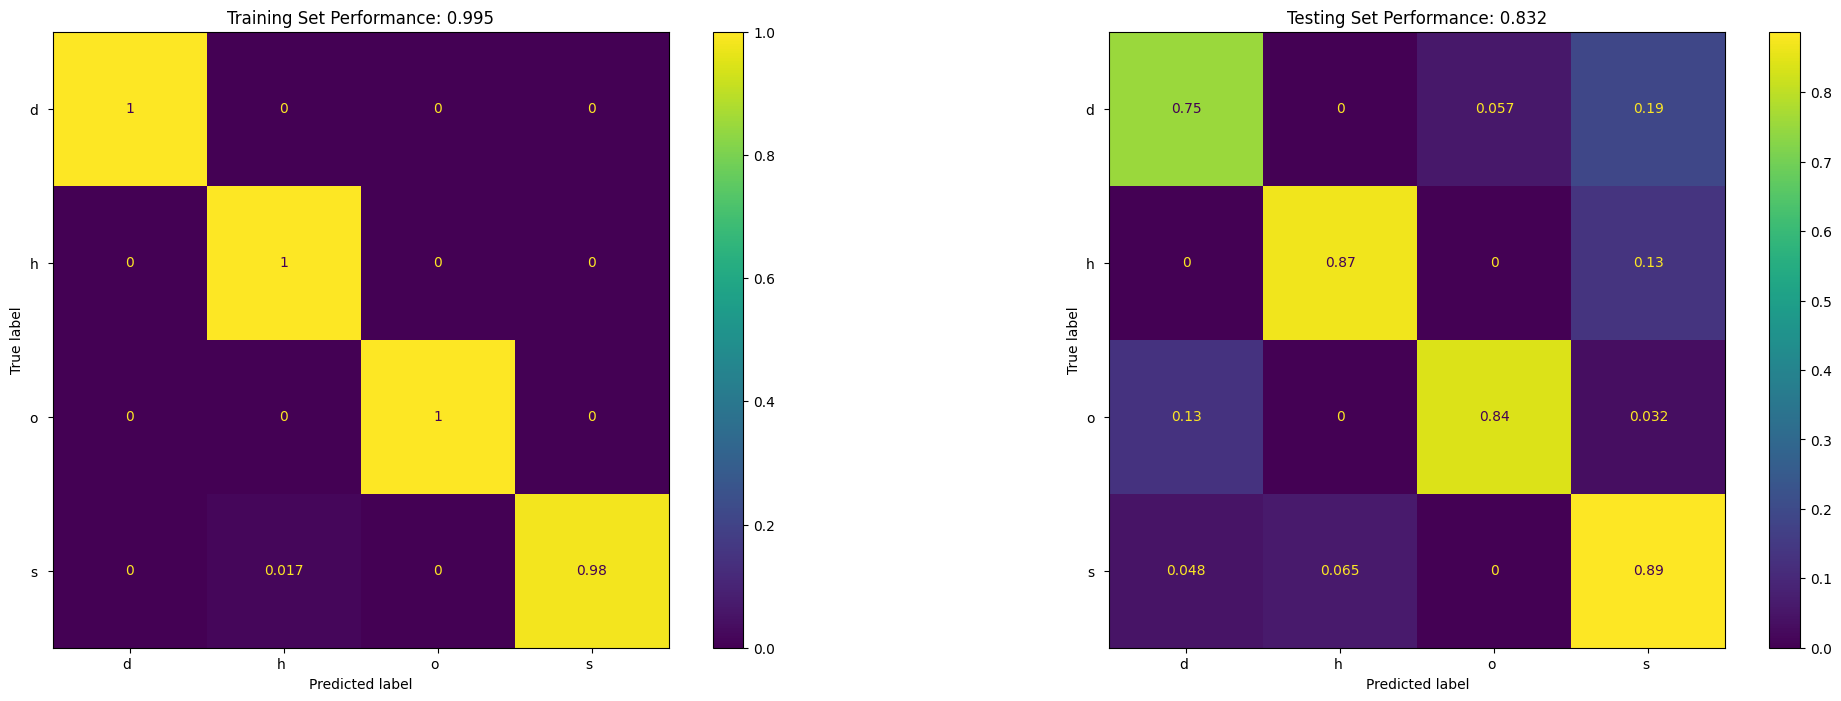

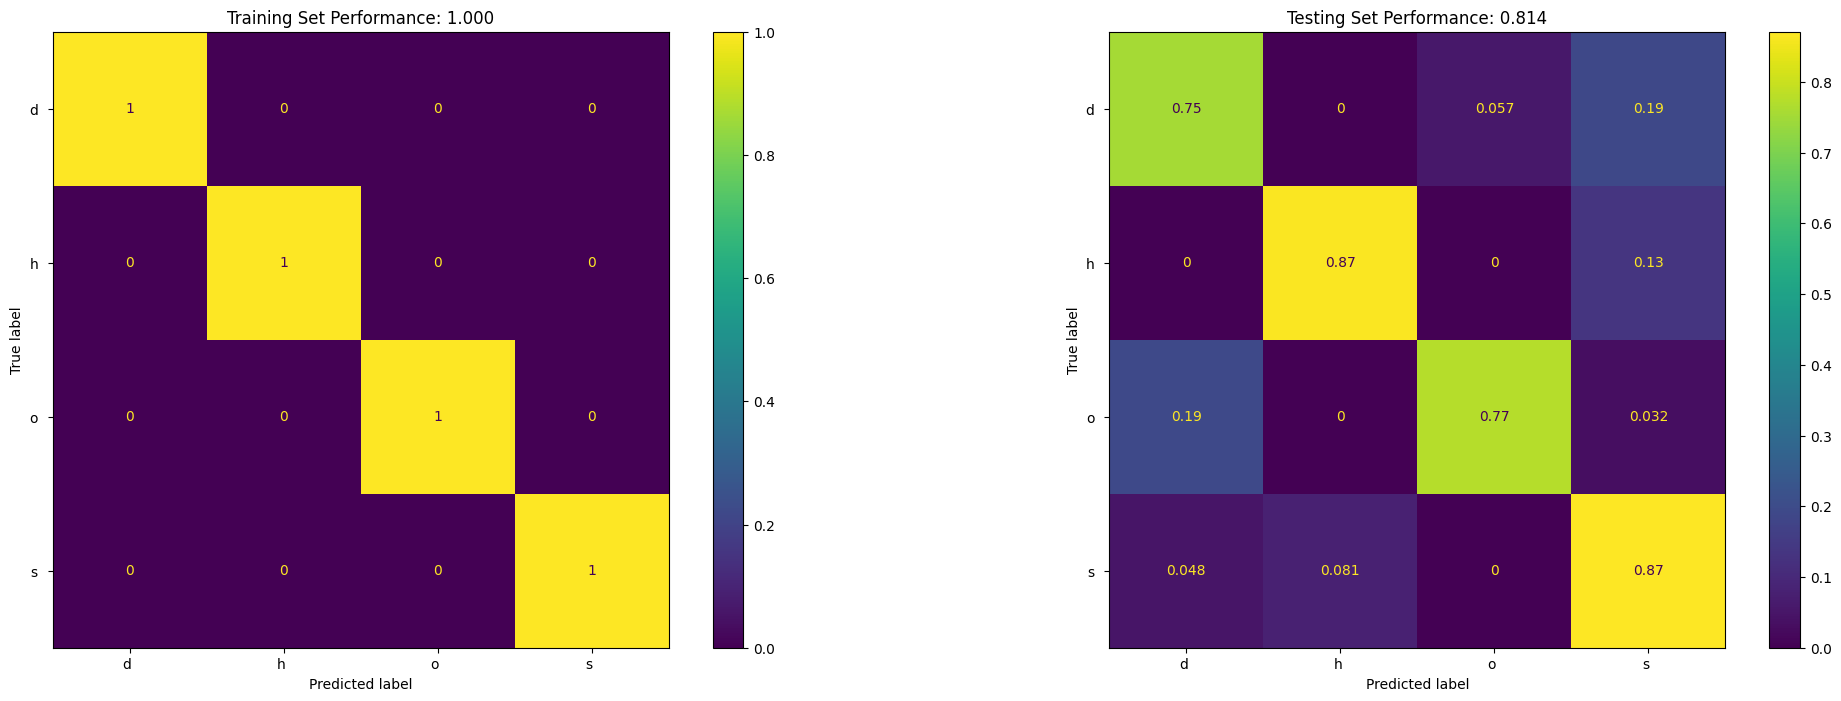

In [28]:
# Train your RF. You should consider the following parameters at least:
#  - Tree depth
#  - Number of estimators
# Please note, you'd don't need to find the "perfect" parameters. The grid search does not need to consider every possible value,
# and can be quite coarse to avoid long run-times. You may also wish to conduct a rough search first, and then a refined search,
# though this is not required.

## ESTIMATOR = 1, DEPTH = 1, 2, 5, 10
#for d in [1,2,5,10]:
  #rf = RandomForestClassifier(n_estimators=1, max_depth=d, random_state=0).fit(X_train, Y_train)
  #rf.fit(X_train, Y_train)
  #eval_model(rf, X_train, Y_train, X_test, Y_test)
#for d in [1,2,5,10]:
  #rf = RandomForestClassifier(n_estimators=10, max_depth=d, random_state=0).fit(X_train, Y_train)
  #rf.fit(X_train, Y_train)
  #eval_model(rf, X_train, Y_train, X_test, Y_test)
#for d in [1,2,5,10]:
  #rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=0).fit(X_train, Y_train)
  #rf.fit(X_train, Y_train)
  #eval_model(rf, X_train, Y_train, X_test, Y_test)
#for d in [1,2,5,10]:
  #rf = RandomForestClassifier(n_estimators=1000, max_depth=d, random_state=0).fit(X_train, Y_train)
  #rf.fit(X_train, Y_train)
  #eval_model(rf, X_train, Y_train, X_test, Y_test)

## Best depth = 5
#for e in [30,40,50,60,70,80]:
  #rf = RandomForestClassifier(n_estimators=e, max_depth=5, random_state=0).fit(X_train, Y_train)
  #rf.fit(X_train, Y_train)
  #eval_model(rf, X_train, Y_train, X_test, Y_test)

rfBEST = RandomForestClassifier(n_estimators=40, max_depth=5, random_state=0).fit(X_train, Y_train)
print("BEST: estimator = 30, depth = 5")
eval_model(rfBEST, X_train, Y_train, X_test, Y_test)

rfc = RandomForestClassifier(random_state=0)
param_grid = {
    'n_estimators': list(range(1,100)),
    'max_depth' : list(range(10,20))
}
grid_search = GridSearchCV(rfc, param_grid,cv=train_val_split)
grid_search.fit(X_train_and_val, Y_train_and_val)
grid_search.cv_results_
best_system = np.argmin(grid_search.cv_results_['rank_test_score'])
params = grid_search.cv_results_['params'][best_system]
print(params)
rfc = RandomForestClassifier().set_params(**params)
rfc.fit(X_train, Y_train)
eval_model(rfc, X_train, Y_train, X_test, Y_test)

In [ ]:
# Evaluate the three methods. This should consider appropriate performance measures for the classifiers, such as F1, and
# visualisations of performance (i.e. confusion matrices) that demonstrate any difference in perfomance between the models.

In [ ]:
# For your write-up, you should include:
# - a discussion of any pre-processing you did and why; or why you left the data as-is
# - a discussion of how you selected the hyper-parameters for each of your models, and how these may be influenced by any data
#   characteristics, and any effect you may see from the selected hyper-parameters (ie. if you have found a small value for a
#   hyper parameter, what effect will this have on the model compared to a large value?)
# - an evaluation and comparison of three models, which should highlight any differences observed between the models
# Your write-up should be supported by appropriate figures and tables. Figures and tables should have numbers and meaningful captions.
# Note that figures and tables are not included in the page limits.
#
# SEE THE ASSIGNMENT BRIEF ON CANVAS FOR MORE DETAILS AND NOTE THAT A NOTEBOOK FILE DOES NOT CONSTITUTE A VALID SUBMISSION.
# YOU SHOULD WRITE UP YOUR RESPONSE IN A SEPARATE DOCUMENT